In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from gensim.models import Word2Vec
from sklearn.manifold import TSNE
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
import umap

# -------------------------------
# 1. Create sample corpus
# -------------------------------
sentences = [
    ["king", "queen", "man", "woman"],
    ["paris", "france", "berlin", "germany"],
    ["apple", "banana", "fruit"],
    ["car", "bus", "train", "vehicle"],
    ["dog", "cat", "animal"],
    ["lion", "tiger", "animal"],
    ["doctor", "nurse", "hospital"],
    ["teacher", "student", "school"]
]

# -------------------------------
# 2. Train Word2Vec model
# -------------------------------
model = Word2Vec(sentences, vector_size=50, window=3, min_count=1, workers=2)

words = list(model.wv.index_to_key)
vectors = np.array([model.wv[word] for word in words])

print("Words:", words)
print("Vector shape:", vectors.shape)

# -------------------------------
# 3. Plot raw vectors (first 2 dims)
# -------------------------------
plt.figure(figsize=(6,6))
for i, word in enumerate(words):
    plt.scatter(vectors[i, 0], vectors[i, 1])
    plt.text(vectors[i, 0]+0.01, vectors[i, 1]+0.01, word)

plt.title("Raw Word2Vec Vectors (first 2 dimensions)")
plt.grid()
plt.show()

# -------------------------------
# 4. t-SNE Visualization
# -------------------------------
tsne = TSNE(n_components=2, perplexity=5, random_state=42)
tsne_result = tsne.fit_transform(vectors)

plt.figure(figsize=(6,6))
for i, word in enumerate(words):
    plt.scatter(tsne_result[i, 0], tsne_result[i, 1])
    plt.text(tsne_result[i, 0]+0.3, tsne_result[i, 1]+0.3, word)

plt.title("t-SNE Visualization")
plt.grid()
plt.show()

# -------------------------------
# 5. UMAP Visualization
# -------------------------------
reducer = umap.UMAP(random_state=42)
umap_result = reducer.fit_transform(vectors)

plt.figure(figsize=(6,6))
for i, word in enumerate(words):
    plt.scatter(umap_result[i, 0], umap_result[i, 1])
    plt.text(umap_result[i, 0]+0.3, umap_result[i, 1]+0.3, word)

plt.title("UMAP Visualization")
plt.grid()
plt.show()

# -------------------------------
# 6. Hierarchical Clustering
# -------------------------------
linked = linkage(vectors, method='ward')

plt.figure(figsize=(10, 6))
dendrogram(linked,
           labels=words,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=True)

plt.title("Hierarchical Clustering Dendrogram")
plt.xticks(rotation=45)
plt.show()

# -------------------------------
# 7. Agglomerative Clustering labels
# -------------------------------
cluster = AgglomerativeClustering(n_clusters=4)
labels = cluster.fit_predict(vectors)

print("\nCluster Assignments:")
for word, label in zip(words, labels):
    print(f"{word}: Cluster {label}")

# -------------------------------
# 8. Similarity Example (Word2Vec power)
# -------------------------------
print("\nMost similar to 'king':")
print(model.wv.most_similar("king"))

# Analogy example
print("\nking - man + woman ≈ ?")
result = model.wv.most_similar(positive=["king", "woman"], negative=["man"])
print(result)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding shape: (12, 384)


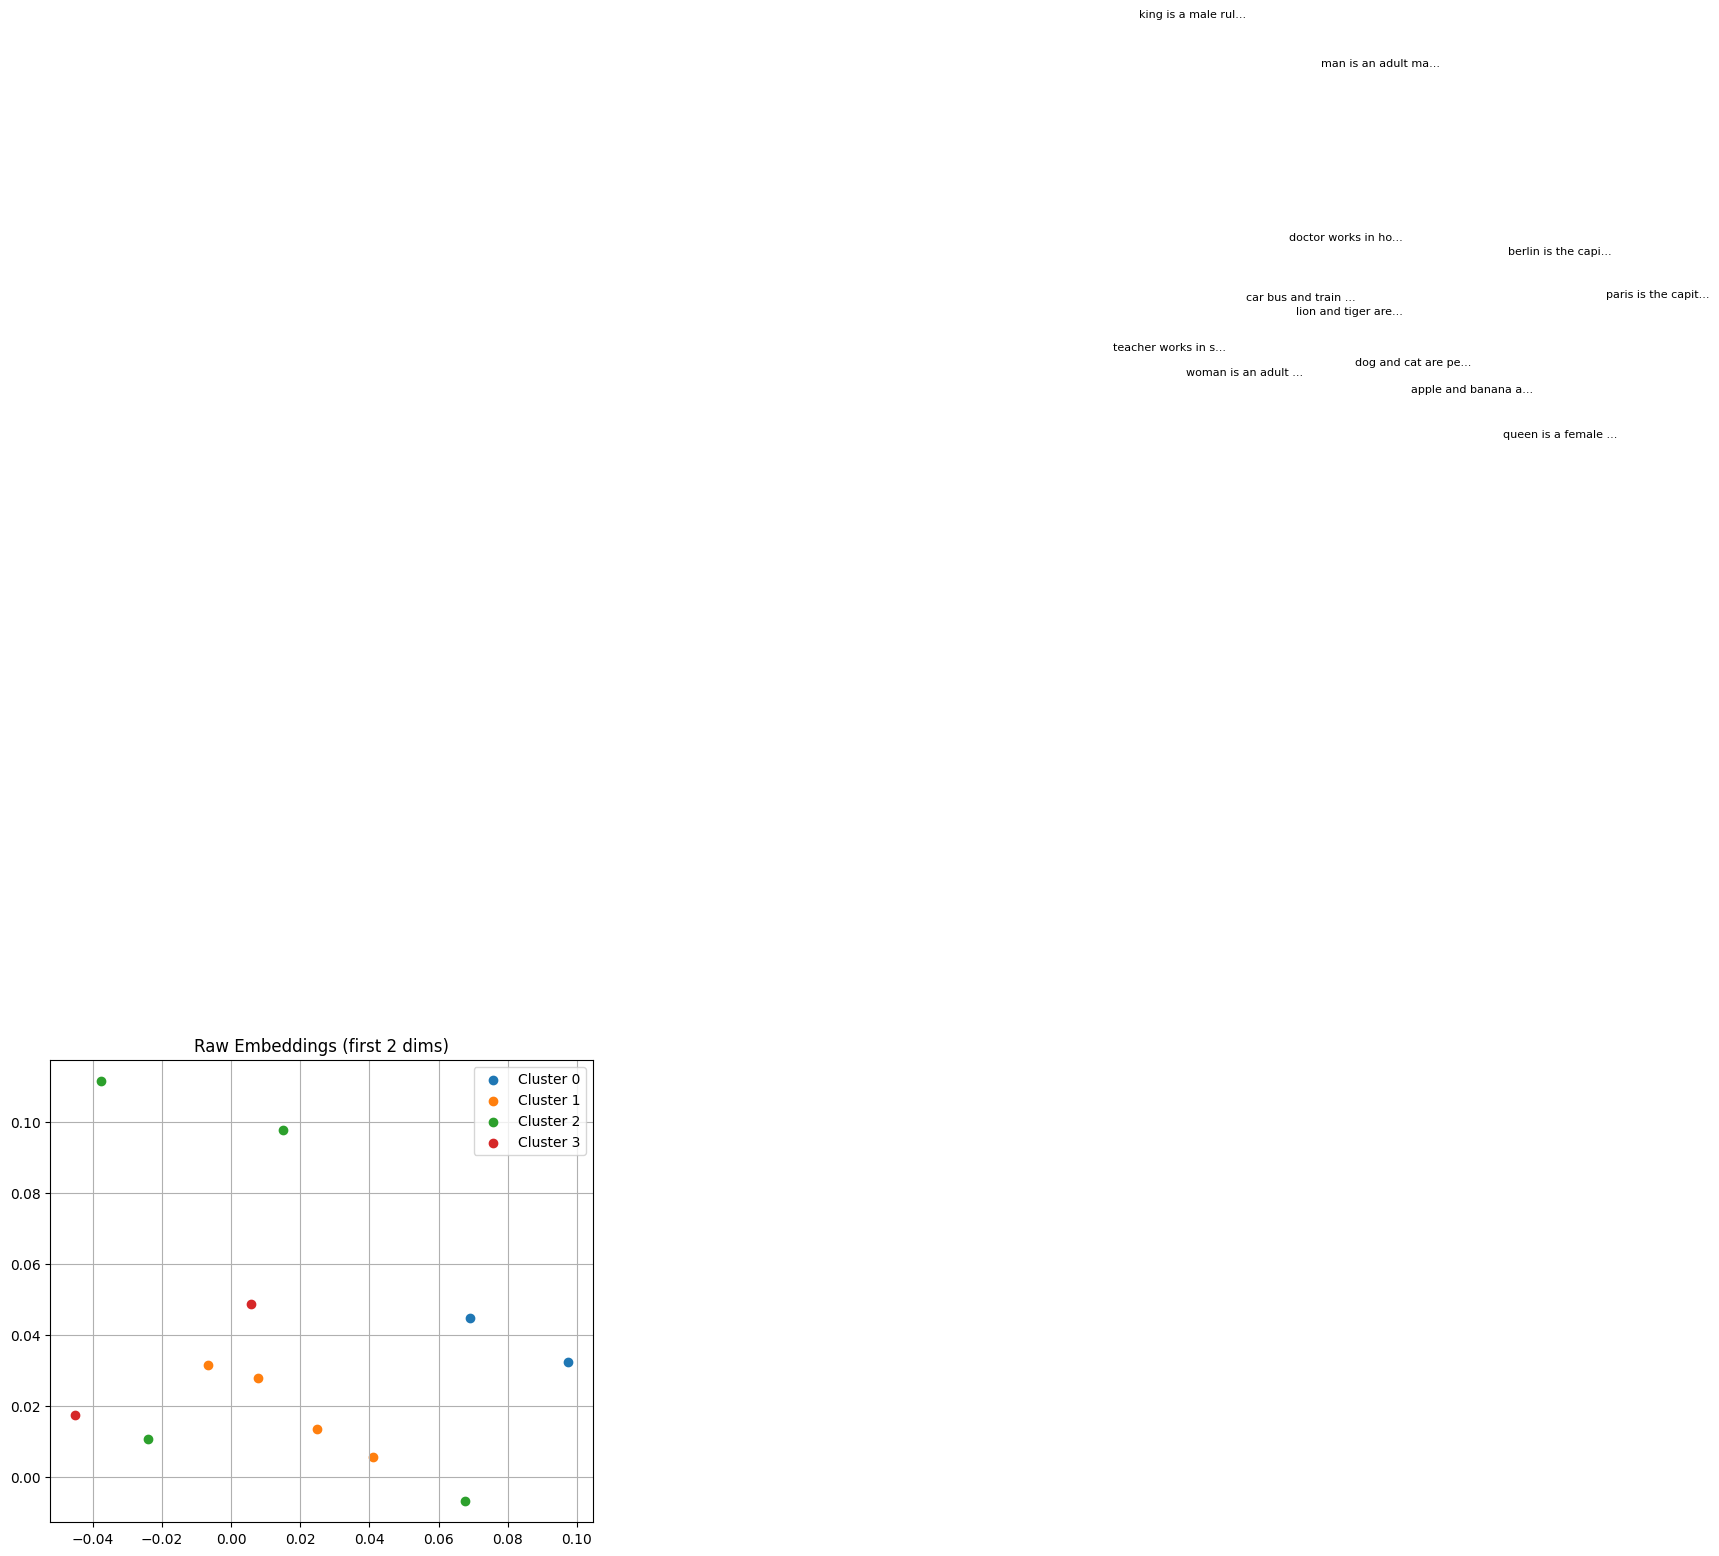

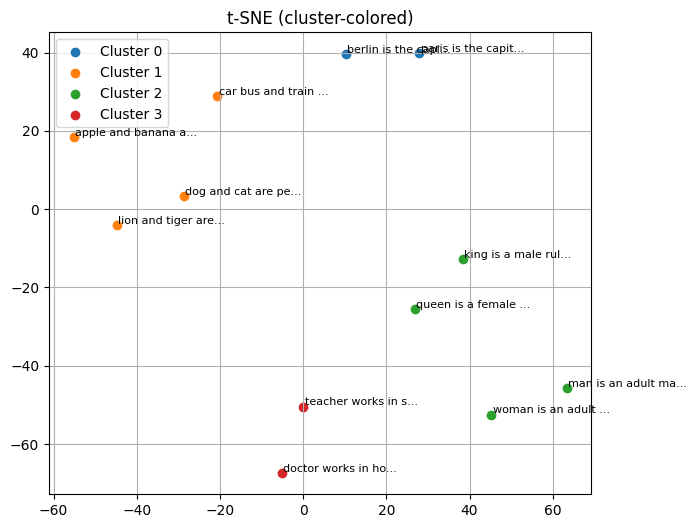

/Users/rahulmishra/Code/personal/Building_AI_Agent/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/rahulmishra/Code/personal/Building_AI_Agent/.venv/lib/python3.14/site-packages/umap/umap_.py:2462: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(


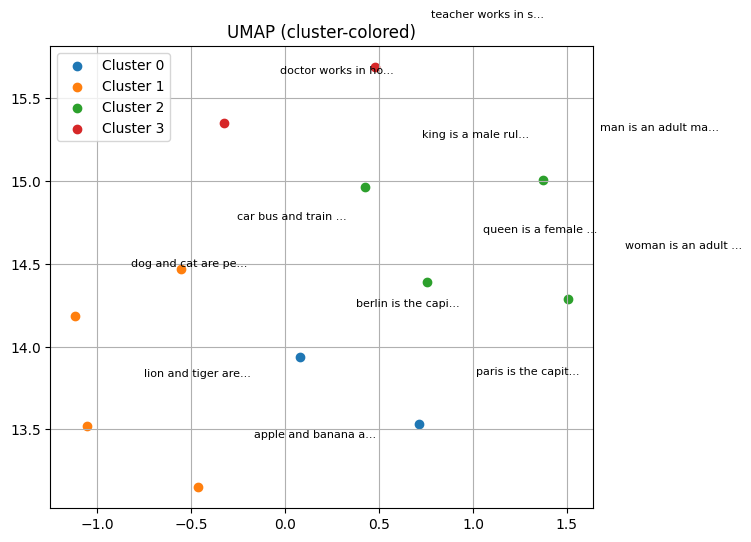

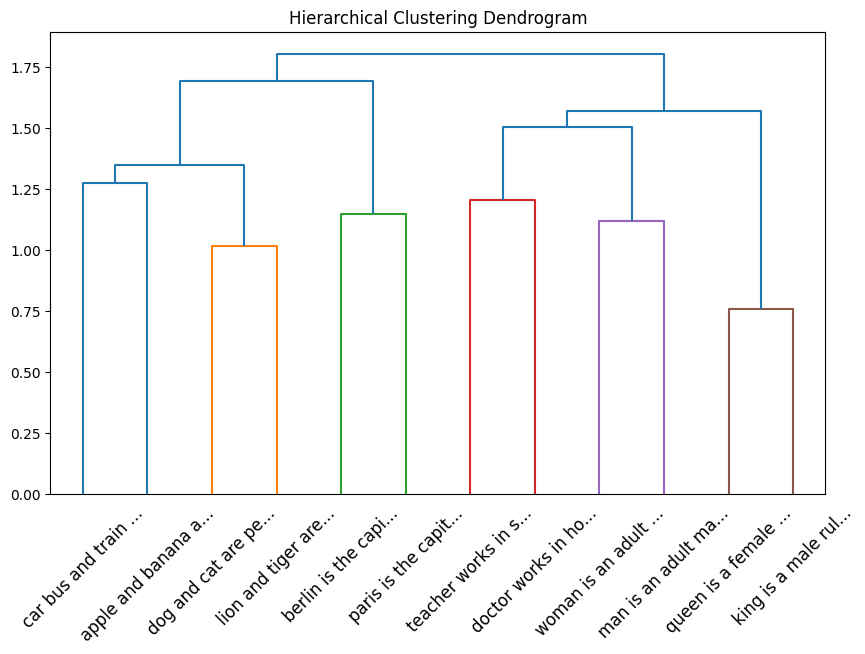


Cluster assignments:
[Cluster 2] king is a male ruler
[Cluster 2] queen is a female ruler
[Cluster 2] man is an adult male
[Cluster 2] woman is an adult female
[Cluster 0] paris is the capital of france
[Cluster 0] berlin is the capital of germany
[Cluster 1] apple and banana are fruits
[Cluster 1] lion and tiger are wild animals
[Cluster 1] dog and cat are pets
[Cluster 1] car bus and train are vehicles
[Cluster 3] doctor works in hospital
[Cluster 3] teacher works in school

Similarity to query: royal king
king is a male ruler -> 0.717
queen is a female ruler -> 0.612
man is an adult male -> 0.157
woman is an adult female -> 0.081
paris is the capital of france -> 0.071
berlin is the capital of germany -> 0.038
apple and banana are fruits -> 0.115
lion and tiger are wild animals -> 0.137
dog and cat are pets -> 0.034
car bus and train are vehicles -> 0.060
doctor works in hospital -> 0.210
teacher works in school -> 0.222


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
from scipy.cluster.hierarchy import dendrogram, linkage
import umap

# -------------------------------
# 1. Sample data
# -------------------------------
sentences = [
    "king is a male ruler",
    "queen is a female ruler",
    "man is an adult male",
    "woman is an adult female",
    "paris is the capital of france",
    "berlin is the capital of germany",
    "apple and banana are fruits",
    "lion and tiger are wild animals",
    "dog and cat are pets",
    "car bus and train are vehicles",
    "doctor works in hospital",
    "teacher works in school"
]

# -------------------------------
# 2. Embeddings
# -------------------------------
model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = model.encode(sentences)

print("Embedding shape:", embeddings.shape)

# -------------------------------
# 3. Clustering (for colors)
# -------------------------------
kmeans = KMeans(n_clusters=4, random_state=42)
cluster_labels = kmeans.fit_predict(embeddings)

# -------------------------------
# Helper: short labels
# -------------------------------
def short_label(text):
    return text[:18] + "..." if len(text) > 18 else text

# -------------------------------
# Helper: plotting function
# -------------------------------
def plot_points(X, title):
    plt.figure(figsize=(7,6))

    for i, text in enumerate(sentences):
        plt.scatter(
            X[i, 0],
            X[i, 1],
            c=f"C{cluster_labels[i]}"
        )
        plt.text(
            X[i, 0] + 0.3,
            X[i, 1] + 0.3,
            short_label(text),
            fontsize=8
        )

    # legend
    for c in set(cluster_labels):
        plt.scatter([], [], c=f"C{c}", label=f"Cluster {c}")

    plt.legend()
    plt.title(title)
    plt.grid()
    plt.show()

# -------------------------------
# 4. Raw embeddings (first 2 dims)
# -------------------------------
plot_points(embeddings[:, :2], "Raw Embeddings (first 2 dims)")

# -------------------------------
# 5. t-SNE
# -------------------------------
tsne = TSNE(n_components=2, perplexity=5, random_state=42)
tsne_result = tsne.fit_transform(embeddings)

plot_points(tsne_result, "t-SNE (cluster-colored)")

# -------------------------------
# 6. UMAP
# -------------------------------
reducer = umap.UMAP(random_state=42)
umap_result = reducer.fit_transform(embeddings)

plot_points(umap_result, "UMAP (cluster-colored)")

# -------------------------------
# 7. Dendrogram
# -------------------------------
linked = linkage(embeddings, method='ward')

plt.figure(figsize=(10, 6))
dendrogram(
    linked,
    labels=[short_label(s) for s in sentences],
    orientation='top',
    distance_sort='descending'
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xticks(rotation=45)
plt.show()

# -------------------------------
# 8. Cluster assignments
# -------------------------------
print("\nCluster assignments:")
for i, text in enumerate(sentences):
    print(f"[Cluster {cluster_labels[i]}] {text}")

# -------------------------------
# 9. Similarity example
# -------------------------------
query = "royal king"
query_embedding = model.encode([query])

similarities = cosine_similarity(query_embedding, embeddings)[0]

print("\nSimilarity to query:", query)
for i, score in enumerate(similarities):
    print(f"{sentences[i]} -> {score:.3f}")